In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

GA_RED = '#e32128'

In [5]:
lung = pd.read_csv('../data/lung-deaths.csv')
lung.date = pd.to_datetime(lung.date)
lung.set_index('date', inplace=True)

In [20]:
jj = pd.read_csv('../data/jj-sales.csv')
jj.date = pd.to_datetime(jj.date)
jj.set_index('date', inplace=True)

In [53]:
bj = pd.read_csv('../data/bj-sales.csv')
bj.set_index('timestamp', inplace=True)

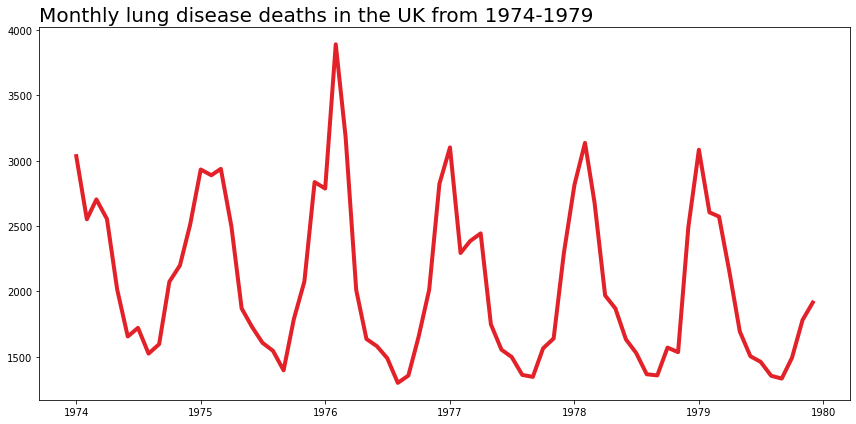

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(lung, c=GA_RED, linewidth=4)
plt.title('Monthly lung disease deaths in the UK from 1974-1979', size=20, loc='left')
plt.tight_layout()
plt.savefig('lung-deaths.png', dpi=192);

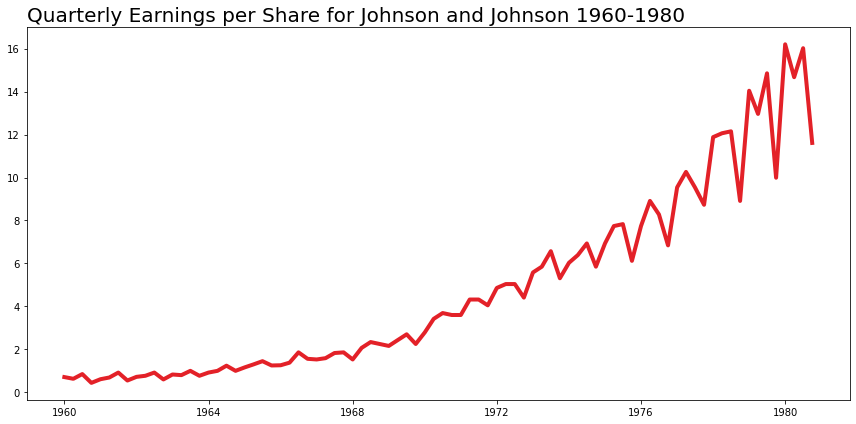

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(jj, c=GA_RED, linewidth=4)
plt.title('Quarterly Earnings per Share for Johnson and Johnson 1960-1980', size=20, loc='left')
plt.tight_layout()
plt.savefig('jj-earnings.png', dpi=192);

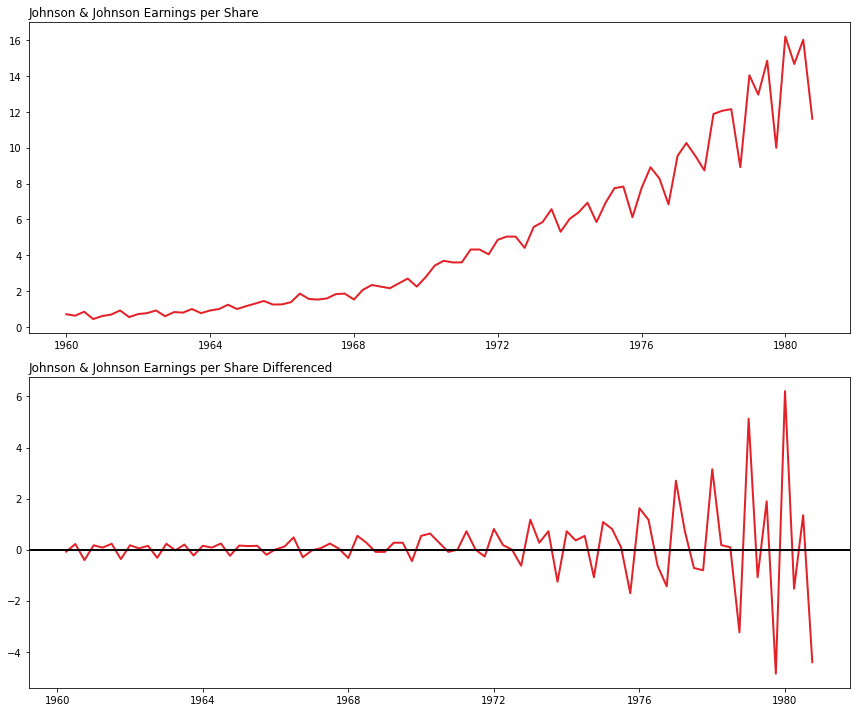

In [47]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

axs[0].set_title('Johnson & Johnson Earnings per Share', loc='left')
axs[0].plot(jj, c=GA_RED, linewidth=2)

axs[1].set_title('Johnson & Johnson Earnings per Share Differenced', loc='left')
axs[1].plot(jj.diff(), c=GA_RED, linewidth=2)
axs[1].axhline(0, c='black', linewidth=2)

plt.tight_layout()
plt.savefig('jj-earnings-diff.png', dpi=192);

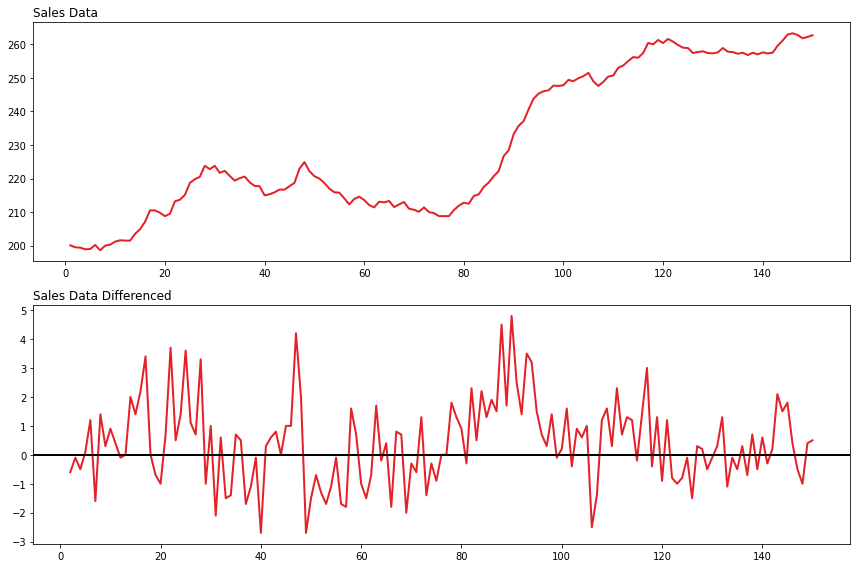

In [57]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

axs[0].set_title('Sales Data', loc='left')
axs[0].plot(bj, c=GA_RED, linewidth=2)

axs[1].set_title('Sales Data Differenced', loc='left')
axs[1].plot(bj.diff(), c=GA_RED, linewidth=2)
axs[1].axhline(0, c='black', linewidth=2)

plt.tight_layout()
plt.savefig('bj-earnings-diff.png', dpi=192);

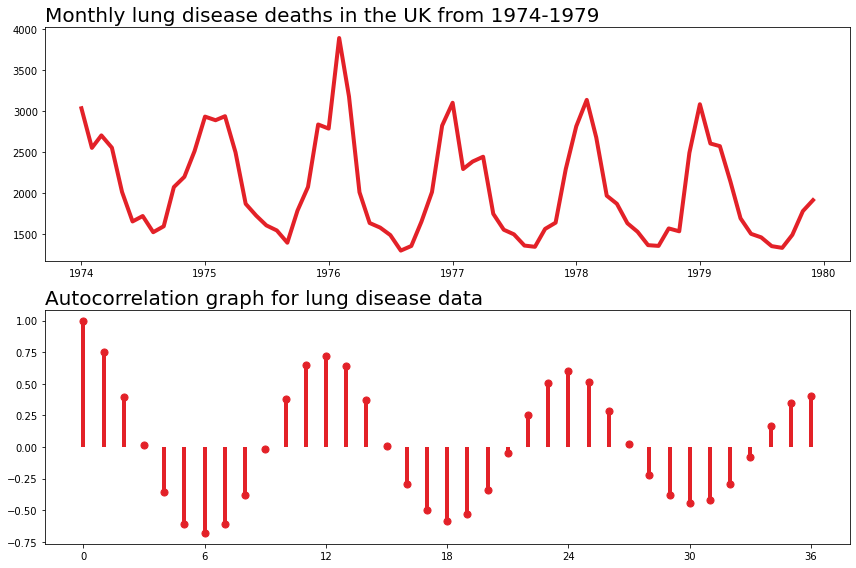

In [127]:
acfs = acf(lung.deaths, nlags=36, fft=False)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))
axs[0].plot(bj, c=GA_RED, linewidth=4)
axs[0].set_title('Monthly lung disease deaths in the UK from 1974-1979', size=20, loc='left')

axs[1].set_title('Autocorrelation graph for lung disease data', size=20, loc='left')
axs[1].bar(np.arange(37), acfs, color=GA_RED, width=0.2)
axs[1].scatter(np.arange(37), acfs, color=GA_RED, s=50)
axs[1].set_xticks([0, 6, 12, 18, 24, 30, 36])

plt.tight_layout()
plt.savefig('lung-acf.png', dpi=192)

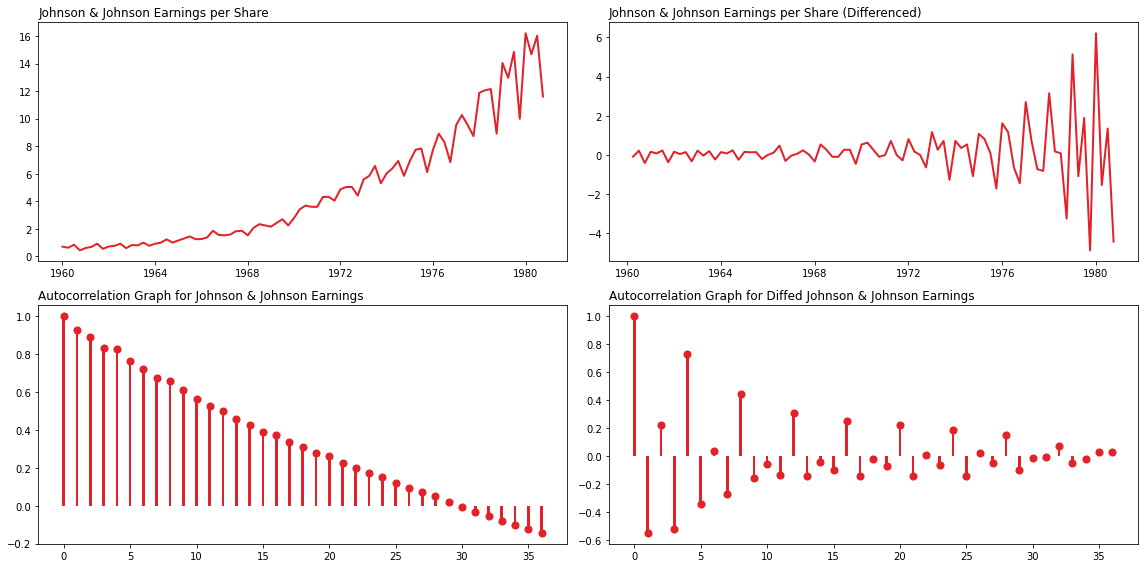

In [163]:

fig, axs = plt.subplots(2, 2, figsize=(16, 8))

axs[0][0].set_title('Johnson & Johnson Earnings per Share', loc='left')
axs[0][0].plot(jj, c=GA_RED, linewidth=2)

axs[0][1].set_title('Johnson & Johnson Earnings per Share (Differenced)', loc='left')
axs[0][1].plot(jj.diff(), c=GA_RED, linewidth=2)

acfs = acf(jj.earnings, nlags=36)
axs[1][0].set_title('Autocorrelation Graph for Johnson & Johnson Earnings', loc='left')
axs[1][0].bar(np.arange(37), acfs, color=GA_RED, width=0.2)
axs[1][0].scatter(np.arange(37), acfs, color=GA_RED, s=50)

dacfs = acf(jj.earnings.diff().dropna(), nlags=36)
axs[1][1].set_title('Autocorrelation Graph for Diffed Johnson & Johnson Earnings', loc='left')
axs[1][1].bar(np.arange(37), dacfs, color=GA_RED, width=0.2)
axs[1][1].scatter(np.arange(37), dacfs, color=GA_RED, s=50)

plt.tight_layout()
plt.savefig('jj-acf.png', dpi=192)

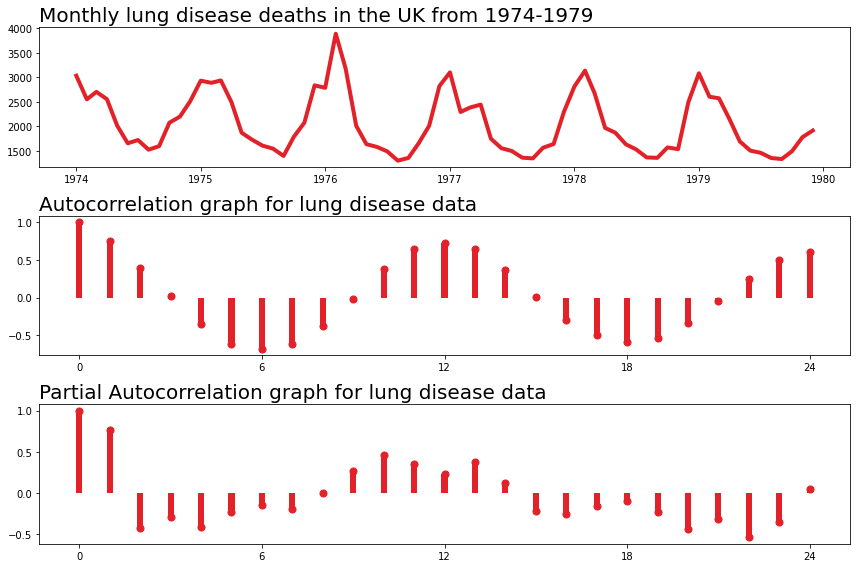

In [178]:
h_max = 24

acfs = acf(lung.deaths, nlags=h_max, fft=False)
pacfs = pacf(lung.deaths, nlags=h_max)

fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs[0].plot(lung, c=GA_RED, linewidth=4)
axs[0].set_title('Monthly lung disease deaths in the UK from 1974-1979', size=20, loc='left')

axs[1].set_title('Autocorrelation graph for lung disease data', size=20, loc='left')
axs[1].bar(np.arange(h_max + 1), acfs, color=GA_RED, width=0.2)
axs[1].scatter(np.arange(h_max + 1), acfs, color=GA_RED, s=50)
axs[1].set_xticks([0, 6, 12, 18, 24])

axs[2].set_title('Partial Autocorrelation graph for lung disease data', size=20, loc='left')
axs[2].bar(np.arange(h_max + 1), pacfs, color=GA_RED, width=0.2)
axs[2].scatter(np.arange(h_max + 1), pacfs, color=GA_RED, s=50)
axs[2].set_xticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.savefig('lung-pacf.png', dpi=192)

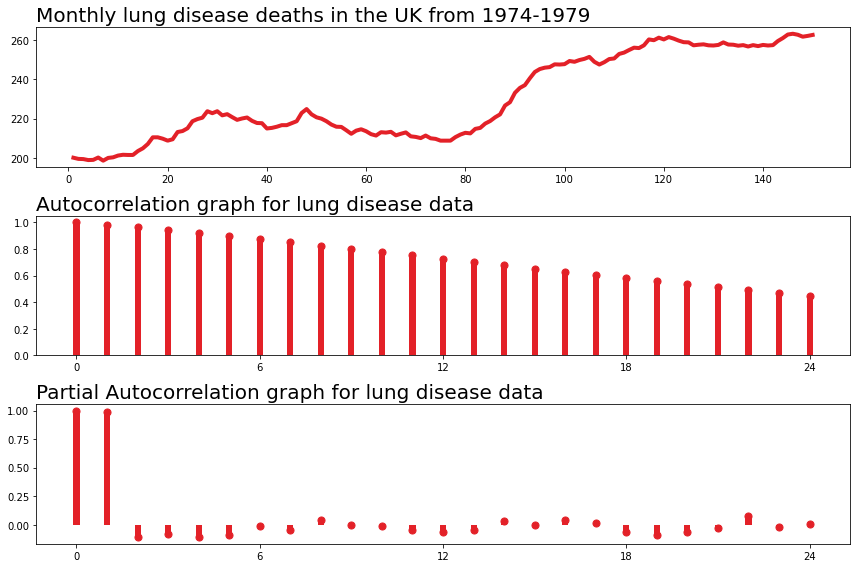

In [177]:
h_max = 24

acfs = acf(bj, nlags=h_max, fft=False)
pacfs = pacf(bj, nlags=h_max)

fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs[0].plot(bj, c=GA_RED, linewidth=4)
axs[0].set_title('Monthly lung disease deaths in the UK from 1974-1979', size=20, loc='left')

axs[1].set_title('Autocorrelation graph for lung disease data', size=20, loc='left')
axs[1].bar(np.arange(h_max + 1), acfs, color=GA_RED, width=0.2)
axs[1].scatter(np.arange(h_max + 1), acfs, color=GA_RED, s=50)
axs[1].set_xticks([0, 6, 12, 18, 24])

axs[2].set_title('Partial Autocorrelation graph for lung disease data', size=20, loc='left')
axs[2].bar(np.arange(h_max + 1), pacfs, color=GA_RED, width=0.2)
axs[2].scatter(np.arange(h_max + 1), pacfs, color=GA_RED, s=50)
axs[2].set_xticks([0, 6, 12, 18, 24])

plt.tight_layout()
plt.savefig('bj-pacf.png', dpi=192)